In [1]:
import pandas as pd

df_droid = pd.read_json('../basic/droid_results.jsonl', lines=True)
df_raft = pd.read_json('../basic/raft_results.jsonl', lines=True)

df_combined = pd.merge(df_droid, df_raft, on='folder')
print(df_combined.head())

              folder  droid_score  raft_score
0  lift_eggplant_s42     0.095967    0.216199
1  lift_eggplant_s43     0.110947    0.280372
2  lift_eggplant_s44     0.193749    0.340390
3  lift_eggplant_s45     0.205347    0.308805
4  lift_eggplant_s46     0.131486    0.306183


In [3]:
import numpy as np

def percentile_norm(x):
    x = np.asarray(x)
    return np.argsort(np.argsort(x)) / len(x)

In [4]:
droid_score = percentile_norm(df_combined['droid_score'])
print(droid_score)

[0.         0.06       0.57333333 0.64       0.16       0.52
 0.61333333 0.68       0.78666667 0.99333333 0.94       0.94666667
 0.56666667 0.30666667 0.36666667 0.47333333 0.15333333 0.46
 0.72       0.11333333 0.65333333 0.88666667 0.21333333 0.38666667
 0.51333333 0.24       0.16666667 0.2        0.59333333 0.90666667
 0.40666667 0.26666667 0.41333333 0.87333333 0.22       0.55333333
 0.28       0.14       0.68666667 0.49333333 0.80666667 0.86666667
 0.91333333 0.54666667 0.92666667 0.43333333 0.74       0.79333333
 0.42       0.84666667 0.95333333 0.98666667 0.25333333 0.3
 0.58666667 0.72666667 0.48       0.93333333 0.84       0.67333333
 0.85333333 0.75333333 0.76666667 0.71333333 0.20666667 0.83333333
 0.13333333 0.81333333 0.04       0.31333333 0.12666667 0.92
 0.08       0.27333333 0.12       0.09333333 0.10666667 0.02666667
 0.32666667 0.8        0.39333333 0.96       0.04666667 0.34666667
 0.35333333 0.07333333 0.23333333 0.66       0.56       0.60666667
 0.78       0.086666

In [5]:
raft_score = percentile_norm(df_combined['raft_score'])
print(raft_score)

[0.         0.08       0.18666667 0.14       0.12       0.03333333
 0.07333333 0.02666667 0.10666667 0.17333333 0.06666667 0.20666667
 0.36       0.06       0.28       0.04       0.01333333 0.02
 0.24666667 0.18       0.14666667 0.09333333 0.13333333 0.00666667
 0.12666667 0.05333333 0.08666667 0.1        0.32       0.22
 0.63333333 0.41333333 0.54       0.56       0.78       0.64666667
 0.76       0.44666667 0.88666667 0.76666667 0.82666667 0.82
 0.96666667 0.79333333 0.66666667 0.62       0.52666667 0.86666667
 0.6        0.97333333 0.38       0.75333333 0.96       0.86
 0.74666667 0.77333333 0.58666667 0.91333333 0.69333333 0.83333333
 0.98666667 0.95333333 0.93333333 0.9        0.92666667 0.72
 0.78666667 0.4        0.58       0.94666667 0.94       0.92
 0.80666667 0.85333333 0.73333333 0.42       0.90666667 0.61333333
 0.99333333 0.88       0.27333333 0.89333333 0.8        0.47333333
 0.67333333 0.52       0.81333333 0.98       0.84666667 0.72666667
 0.39333333 0.26       0.333333

Text(0.5, 1.0, 'RAFT percentile')

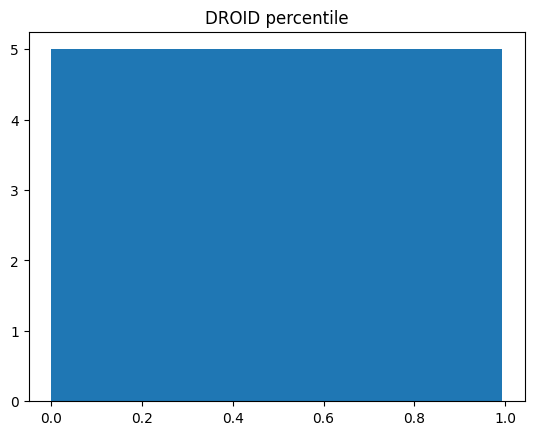

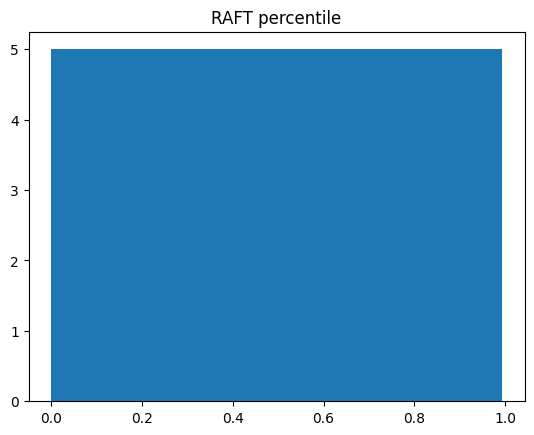

In [6]:
import matplotlib.pyplot as plt

plt.hist(droid_score, bins=30)
plt.title("DROID percentile")

plt.figure()
plt.hist(raft_score, bins=30)
plt.title("RAFT percentile")

In [7]:
def entropy(x, bins=30):
    hist, _ = np.histogram(x, bins=bins, range=(0,1), density=True)
    hist = hist + 1e-8
    hist = hist / hist.sum()
    return -np.sum(hist * np.log(hist))

In [10]:
H_d = entropy(df_combined['droid_score'])
H_r = entropy(df_combined['raft_score'])

In [11]:
print(H_d, H_r)

2.1632152078264357 2.8858545480394127


In [ ]:
w_d = 1 / H_d
w_r = 1 / H_r

w_sum = w_d + w_r
w_d /= w_sum
w_r /= w_sum

In [12]:
w_d = np.exp(-H_d)
w_r = np.exp(-H_r)

w_sum = w_d + w_r
w_d /= w_sum
w_r /= w_sum

In [13]:
print(w_d, w_r)

0.673187952783446 0.326812047216554


In [14]:
score = w_d * droid_score + w_r * raft_score
print(score)

[0.         0.06653624 0.44696601 0.47659398 0.14692752 0.36095147
 0.43685483 0.4664828  0.56443447 0.72534745 0.65458415 0.70482575
 0.49912551 0.22605303 0.33834296 0.33171478 0.10757965 0.3162027
 0.56530896 0.1351208  0.48774856 0.62739578 0.18718837 0.26247809
 0.38696601 0.17899508 0.1405217  0.1673188  0.50400471 0.68225573
 0.48074406 0.3145991  0.45472953 0.77093223 0.40301475 0.58383579
 0.43686978 0.24022236 0.75202908 0.58266196 0.81320291 0.85141544
 0.93076331 0.6272803  0.84169553 0.49433825 0.6702801  0.81729955
 0.47882617 0.88806286 0.76596109 0.91041052 0.48428051 0.48301475
 0.63895659 0.7419179  0.51485995 0.92679709 0.79206757 0.72562326
 0.89690827 0.81869574 0.82113534 0.77433825 0.44197134 0.79629463
 0.34685054 0.67825102 0.21647851 0.5203143  0.3924738  0.92
 0.31748342 0.46288432 0.32044472 0.20009194 0.3681163  0.2183964
 0.54454136 0.82614496 0.35411589 0.93821253 0.29286508 0.38806286
 0.45791319 0.21930938 0.42288432 0.76457986 0.65368612 0.64588411
 0.

In [15]:
threshold = np.percentile(score, 90)

In [ ]:
print(threshold)  # 상위 10%

0.817439169393957


In [17]:
df_combined['combined_score'] = score
print(df_combined.head())

              folder  droid_score  raft_score  combined_score
0  lift_eggplant_s42     0.095967    0.216199        0.000000
1  lift_eggplant_s43     0.110947    0.280372        0.066536
2  lift_eggplant_s44     0.193749    0.340390        0.446966
3  lift_eggplant_s45     0.205347    0.308805        0.476594
4  lift_eggplant_s46     0.131486    0.306183        0.146928


In [18]:
print(df_combined.sort_values(by='combined_score', ascending=False).head())

                       folder  droid_score  raft_score  combined_score
81    put_carrot_on_plate_s63     0.472375    1.090889        0.938213
42  put_blue_cup_on_plate_s54     0.352650    1.553561        0.930763
57  put_blue_cup_on_plate_s69     0.401301    1.098498        0.926797
71    put_carrot_on_plate_s53     0.363444    1.123761        0.920000
51  put_blue_cup_on_plate_s63     0.799080    0.737066        0.910411


In [ ]:
# 평균 0, 표준편차 1로 변환: Z-Score Normalization
df_combined['droid_std'] = (df_combined['droid_score'] - df_combined['droid_score'].mean()) / df_combined['droid_score'].std()
df_combined['raft_std'] = (df_combined['raft_score'] - df_combined['raft_score'].mean()) / df_combined['raft_score'].std()

# 가중치 적용
df_combined['combined_score'] = w_d * df_combined['droid_std'] + w_r * df_combined['raft_std']

In [20]:
print(df_combined.sort_values(by='combined_score', ascending=False).head())

                             folder  droid_score  raft_score  combined_score  \
51        put_blue_cup_on_plate_s63     0.799080    0.737066        3.410912   
9                 lift_eggplant_s51     0.837242    0.323006        3.232289   
124  stack_blue_cup_on_pink_cup_s46     0.760439    0.531731        2.998941   
81          put_carrot_on_plate_s63     0.472375    1.090889        1.911397   
126  stack_blue_cup_on_pink_cup_s48     0.550835    0.473638        1.766298   

     droid_std  raft_std  
51    4.892176  0.359712  
9     5.210636 -0.842835  
124   4.569715 -0.236638  
81    2.165823  1.387315  
126   2.820570 -0.405357  


In [22]:
print(df_combined.sort_values(by='combined_score', ascending=True).head())

                        folder  droid_score  raft_score  combined_score  \
0            lift_eggplant_s42     0.095967    0.216199       -1.033376   
98   put_eggplant_into_pot_s50     0.097745    0.355921       -0.890775   
110  put_eggplant_into_pot_s62     0.097193    0.360148       -0.889863   
1            lift_eggplant_s43     0.110947    0.280372       -0.888314   
114  put_eggplant_into_pot_s66     0.106251    0.374993       -0.824888   

     droid_std  raft_std  
0    -0.975286 -1.153033  
98   -0.960456 -0.747241  
110  -0.965061 -0.734965  
1    -0.850280 -0.966658  
114  -0.889473 -0.691851  


In [23]:
df_combined['task'] = df_combined['folder'].str.extract(r'^(.*)_s\d+')
df_sorted = df_combined.sort_values(by=['task', 'combined_score'], ascending=[True, False])
df_top10 = df_sorted.groupby('task').head(10)
print(df_top10)

                             folder  droid_score  raft_score  combined_score  \
9                 lift_eggplant_s51     0.837242    0.323006        3.232289   
11                lift_eggplant_s53     0.444649    0.347032        1.049605   
10                lift_eggplant_s52     0.426511    0.272458        0.876929   
29                lift_eggplant_s71     0.351494    0.351585        0.530609   
21                lift_eggplant_s63     0.296184    0.293348        0.164615   
8                 lift_eggplant_s50     0.256419    0.305176       -0.047548   
18                lift_eggplant_s60     0.233855    0.357462       -0.124681   
12                lift_eggplant_s54     0.193413    0.432842       -0.280323   
7                 lift_eggplant_s49     0.223908    0.248685       -0.283806   
20                lift_eggplant_s62     0.211283    0.310080       -0.296456   
51        put_blue_cup_on_plate_s63     0.799080    0.737066        3.410912   
42        put_blue_cup_on_plate_s54     

In [28]:
import shutil
import os

def copy_videos(df, subdir, video_extension='.mp4'):
    source_dir = '/home/yun/world-model-eval/rollouts/openvla_seeds'
    target_dir = source_dir + "/" + subdir
    
    os.makedirs(target_dir, exist_ok=True)

    copy_count = 0
    for _, row in df.iterrows():
        folder_name = row['folder']
        score = round(row['combined_score'], 4)
        score_str = str(round(row['combined_score'], 4)).replace('.', '_')
        
        matched_files = [
            f for f in os.listdir(source_dir)
            if f == folder_name + video_extension
        ]
        
        if matched_files:
            for f in matched_files:
                src_file_path = os.path.join(source_dir, f)
                dst_file_name = f"{folder_name}_{score_str}{video_extension}"
                dst_file_path = os.path.join(target_dir, dst_file_name)
                shutil.copy2(src_file_path, dst_file_path)
                copy_count += 1
        else:
            print(f"파일 없음: {folder_name}")

    print(f"[{target_dir}] 총 {copy_count}개의 영상 추출 완료!")

In [29]:
copy_videos(df_top10, 'top_anomaly')

[/home/yun/world-model-eval/rollouts/openvla_seeds/top_anomaly] 총 50개의 영상 추출 완료!


In [30]:
df_low10 = df_sorted.groupby('task').tail(10)
print(df_low10)

                             folder  droid_score  raft_score  combined_score  \
13                lift_eggplant_s55     0.148835    0.267060       -0.688107   
22                lift_eggplant_s64     0.138499    0.308301       -0.707028   
27                lift_eggplant_s69     0.137634    0.301621       -0.718225   
25                lift_eggplant_s67     0.141980    0.266378       -0.727264   
4                 lift_eggplant_s46     0.131486    0.306183       -0.748435   
19                lift_eggplant_s61     0.125882    0.334788       -0.752764   
26                lift_eggplant_s68     0.131825    0.284561       -0.767050   
16                lift_eggplant_s58     0.130546    0.246555       -0.810308   
1                 lift_eggplant_s43     0.110947    0.280372       -0.888314   
0                 lift_eggplant_s42     0.095967    0.216199       -1.033376   
35        put_blue_cup_on_plate_s47     0.191029    0.644425       -0.092896   
34        put_blue_cup_on_plate_s46     

In [31]:
copy_videos(df_low10, 'low_anomaly')

[/home/yun/world-model-eval/rollouts/openvla_seeds/low_anomaly] 총 50개의 영상 추출 완료!
